# Simon's Algorithm with Qiskit

In [27]:
import math
from pandas import DataFrame as df
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit.visualization import array_to_latex
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

In [28]:
s ='101'

input_qubits = len(str(s))

total_qubits = 2*input_qubits # total qubits includes the input from the first and second quantum register 
qc = QuantumCircuit(total_qubits, input_qubits) #notice for this example: 4 quantum qubits, 2 classical bits (for mesuring the first register)

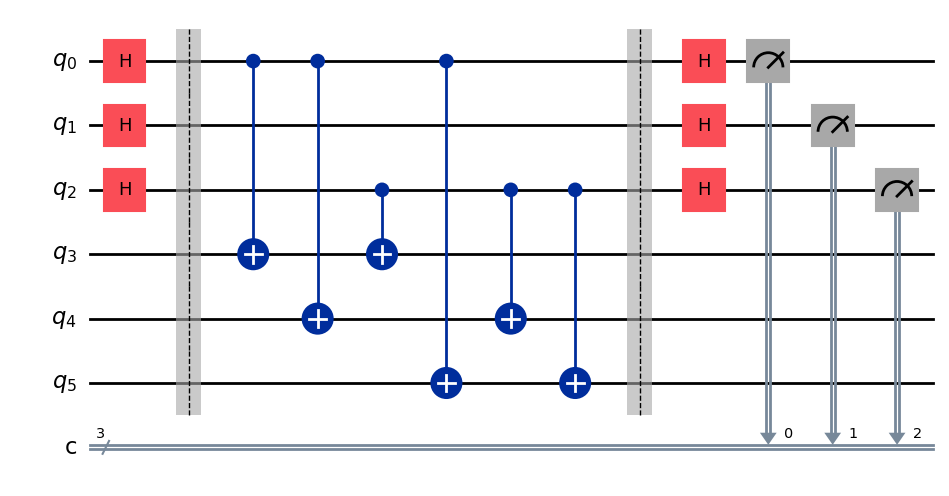

In [29]:
qc.h(range(input_qubits)) # applies hadamrat to all the 1st register
qc.barrier()

for idx in range(input_qubits):
    if (s[idx] == '1'): # if x₀=1, flip BOTH output qubits, if case s[idx]=0 nothing happenes 
        for count in range(input_qubits):
            qc.cx(idx, input_qubits+count)

"""
Why do we want to flip BOTH output qubits if x₀=1? 
ANS: Simon's Algorithm requires The function must be 2-1 with pairing (f(x) = f(x XOR s)). 

So pairing are: 

x     x XOR s
00     10
01     11

So we need f(00) = f(01) and f(x) = f(11). That is it, nothing else.
Notice, second quantum register (x')), always starts with 00. 

x     x0     x'     f(x)
00     0     00     00
01     0     00     00
10     1     00     11
11     1     00     11

notice: f(00) = f(01) and f(x) = f(11). 
Note: there are other ways to achive the same thing (i.e flip only second qubit)
"""
        
qc.barrier()

qc.h(range(len(str(s))))
#qc.h(range(input_qubits))

qc.measure([0,1,2],[0,1,2])

qc.draw('mpl')


Total Counts are: {'000': 497, '101': 503}


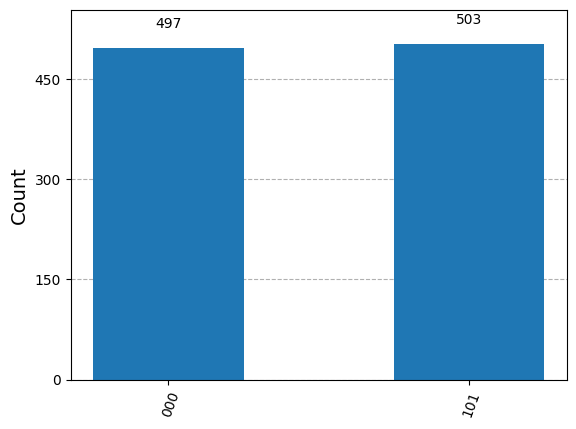

In [30]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)